# **XGBoost Classifier — Hotel Booking Cancellation Prediction**

This notebook covers the full XGBoost modelling pipeline:
1. Data loading & preprocessing
2. Sampling strategy comparison (including sample_weight approach)
3. RandomizedSearchCV hyperparameter tuning on best method
4. Final model evaluation on validation set
5. Feature importance analysis (Gini + Permutation)

---
## **1. Imports**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, f1_score,
                             recall_score, precision_score)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("All libraries imported successfully")

All libraries imported successfully


---
## **2. Preprocessing — Hybrid Encoding (No Log Transform for Tree Models)**

In [7]:
train = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_train.csv")
val   = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_validation.csv")
test  = pd.read_csv("/content/drive/MyDrive/Random forest classifier/Cleaned_original_test.csv")

# STEP 1 — Binary Encoding
binary_cols = ["Gender", "Previous_Cancellations", "Visted_Previously",
               "Use_Promotion", "Required_Car_Parking"]
le = LabelEncoder()
for col in binary_cols:
    le.fit(train[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print("Binary encoding done")

# STEP 2 — Ordinal Encoding
income_order = [["<25K", "25K --50K", "50K -- 100K", ">100K"]]
edu_order    = [["Mid-School", "High-School", "College", "Grad"]]

oe_income = OrdinalEncoder(categories=income_order,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1)
oe_income.fit(train[["Income"]])
train["Income"] = oe_income.transform(train[["Income"]])
val["Income"]   = oe_income.transform(val[["Income"]])
test["Income"]  = oe_income.transform(test[["Income"]])

oe_edu = OrdinalEncoder(categories=edu_order,
                         handle_unknown="use_encoded_value",
                         unknown_value=-1)
oe_edu.fit(train[["Educational_Level"]])
train["Educational_Level"] = oe_edu.transform(train[["Educational_Level"]])
val["Educational_Level"]   = oe_edu.transform(val[["Educational_Level"]])
test["Educational_Level"]  = oe_edu.transform(test[["Educational_Level"]])

print("Ordinal encoding done")

# STEP 3 — Target Encoding for Meal_Type (fit on train only)
meal_target_map = (
    train.groupby("Meal_Type")["Reservation_Status"]
    .apply(lambda x: (x != "Check-In").mean())
    .to_dict()
)
print(f"Meal_Type target encoding map: {meal_target_map}")

train["Meal_Type"] = train["Meal_Type"].map(meal_target_map)
val["Meal_Type"]   = val["Meal_Type"].map(meal_target_map)
test["Meal_Type"]  = test["Meal_Type"].map(meal_target_map).fillna(
    train["Meal_Type"].mean())

print("Target encoding done")

# STEP 4 — OHE
ohe_cols = ["Hotel_Type", "Booking_channel", "Deposit_type",
            "Ethnicity", "Country_region"]

train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
val   = pd.get_dummies(val,   columns=ohe_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

# Clean column names for XGBoost compatibility
for frame in [train, val, test]:
    frame.columns = frame.columns.str.replace("[","",regex=False)\
                                  .str.replace("]","",regex=False)\
                                  .str.replace("<","",regex=False)\
                                  .str.replace(">","",regex=False)\
                                  .str.replace(",","",regex=False)\
                                  .str.replace(" ","_",regex=False)\
                                  .str.replace("-","_",regex=False)

val  = val.reindex(columns=train.columns, fill_value=0)
test = test.reindex(columns=train.columns, fill_value=0)

print(f"\nPreprocessing complete")
print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

Binary encoding done
Ordinal encoding done
Meal_Type target encoding map: {'BB': 0.15960514640638865, 'FB': 0.3828125, 'HB': 0.2543086939869782}
Target encoding done

Preprocessing complete
Train: (17694, 35) | Val: (1784, 35) | Test: (2793, 35)


---
## **3. Encode Target & Prepare X, y**

In [8]:
le_target = LabelEncoder()
le_target.fit(train["Reservation_Status"])

y_train = le_target.transform(train["Reservation_Status"])
y_val   = le_target.transform(val["Reservation_Status"])

print("Classes:", le_target.classes_)
# ['Canceled' 'Check-In' 'No-Show'] → 0, 1, 2

drop_cols = [c for c in ["Reservation_Status", "Booking_date",
                          "Expected_checkin", "Expected_checkout",
                          "Reservation_ID"]
             if c in train.columns]

X_train = train.drop(columns=drop_cols).astype(float)
X_val   = val.drop(columns=drop_cols).astype(float)
X_test  = test.drop(columns=[c for c in drop_cols
                              if c in test.columns]).astype(float)

y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nTrain class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_train == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nVal class distribution:")
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    count = (y_val == idx).sum()
    print(f"  {cls}: {count} ({count/len(y_val)*100:.1f}%)")

Classes: ['Canceled' 'Check-In' 'No-Show']

X_train: (17694, 34)
X_val:   (1784, 34)
X_test:  (2793, 34)

Train class distribution:
  Canceled: 2724 (15.4%)
  Check-In: 13604 (76.9%)
  No-Show: 1366 (7.7%)

Val class distribution:
  Canceled: 491 (27.5%)
  Check-In: 1041 (58.4%)
  No-Show: 252 (14.1%)


---
## **4. Evaluation Function**

In [9]:
def evaluate_model(name, y_true, y_pred, y_prob, y_true_bin, classes):

    acc       = round(accuracy_score(y_true, y_pred), 4)
    prec      = round(precision_score(y_true, y_pred,
                      average="macro", zero_division=0), 4)
    recall    = round(recall_score(y_true, y_pred, average="macro"), 4)
    f1        = round(f1_score(y_true, y_pred, average="macro"), 4)
    auc       = round(roc_auc_score(y_true_bin, y_prob,
                      multi_class="ovr"), 4)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc}")
    print(f"  Precision : {prec}")
    print(f"  Recall    : {recall}")
    print(f"  F1 Macro  : {f1}")
    print(f"  ROC-AUC   : {auc}")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=classes)
    plt.figure(figsize=(8, 6))
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {name}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ROC Curve
    colors = ["steelblue", "orange", "green"]
    plt.figure(figsize=(9, 6))
    for i, (color, cls) in enumerate(zip(colors, classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_cls = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{cls} (AUC={auc_cls:.3f})")
    plt.plot([0,1],[0,1],"r--", label="Random Guess")
    plt.title(f"ROC Curve — {name}", fontsize=13)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": recall, "f1_macro": f1, "roc_auc": auc}

print("Evaluation function ready")

Evaluation function ready


---
## **5. Prepare Sampled Datasets**

Create all sampled versions upfront so we can reuse them cleanly.

In [10]:
# SMOTE — equal classes
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE: {len(X_train_smote)} samples")

# Random Undersampling — equal classes
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"Undersampling: {len(X_train_rus)} samples")

# Exact Validation Distribution Match
# Val: 27.5% Canceled, 58.4% Check-In, 14.1% No-Show
oversample_exact = SMOTE(
    sampling_strategy={0: 2750, 2: 1410},
    random_state=42, k_neighbors=5
)
undersample_exact = RandomUnderSampler(
    sampling_strategy={1: 5840},
    random_state=42
)
exact_pipe = Pipeline([
    ("smote", oversample_exact),
    ("undersample", undersample_exact)
])
X_train_exact, y_train_exact = exact_pipe.fit_resample(X_train, y_train)
print(f"Exact Val Match: {len(X_train_exact)} samples")

# Compute sample weights for class weighting approach
# XGBoost uses sample_weight instead of class_weight
sample_weights = compute_sample_weight(
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    y=y_train
)
sample_weights_exact = compute_sample_weight(
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    y=y_train_exact
)

print("\nAll sampled datasets ready")

SMOTE: 40812 samples
Undersampling: 4098 samples
Exact Val Match: 10000 samples

All sampled datasets ready


---
## **6. Sampling Strategy Comparison**

XGBoost differs from RF in key ways:
- It uses **boosting** (sequential error correction) not bagging
- It handles imbalance via **sample_weight** parameter during fit
- `learning_rate` controls how aggressively it learns from mistakes
- Lower learning rate + more estimators = better generalisation

In [11]:
results = []

### **6.1 Baseline (no balancing)**


  XGB Baseline
  Accuracy  : 0.5807
  Precision : 0.3174
  Recall    : 0.3342
  F1 Macro  : 0.2538
  ROC-AUC   : 0.5027

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.37      0.01      0.03       491
    Check-In       0.58      0.99      0.73      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.32      0.33      0.25      1784
weighted avg       0.44      0.58      0.44      1784



<Figure size 800x600 with 0 Axes>

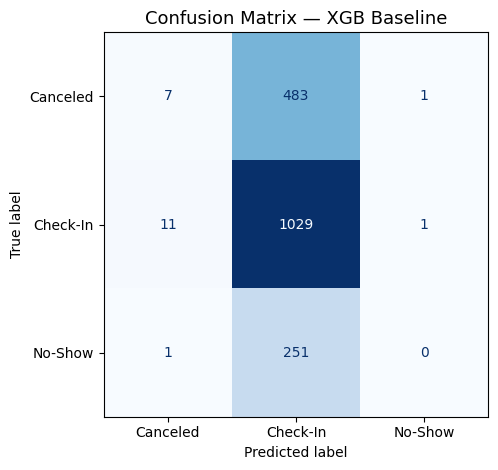

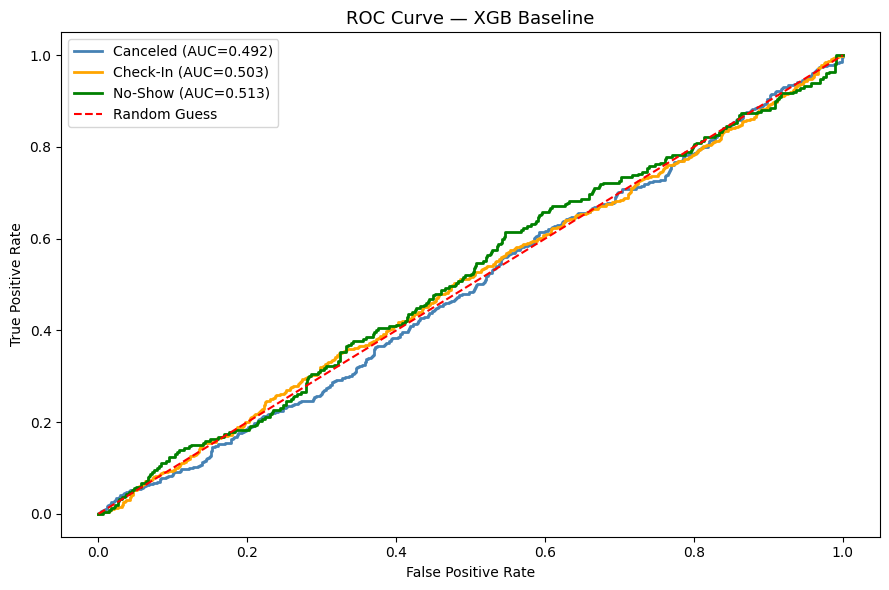

In [12]:
xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)
y_pred = xgb_baseline.predict(X_val)
y_prob = xgb_baseline.predict_proba(X_val)

metrics = evaluate_model("XGB Baseline", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.2 Sample Weights (XGBoost's way of handling class imbalance)**


  XGB Sample Weight
  Accuracy  : 0.5314
  Precision : 0.3348
  Recall    : 0.3316
  F1 Macro  : 0.3006
  ROC-AUC   : 0.4983

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.26      0.11      0.15       491
    Check-In       0.58      0.85      0.69      1041
     No-Show       0.17      0.04      0.06       252

    accuracy                           0.53      1784
   macro avg       0.33      0.33      0.30      1784
weighted avg       0.43      0.53      0.45      1784



<Figure size 800x600 with 0 Axes>

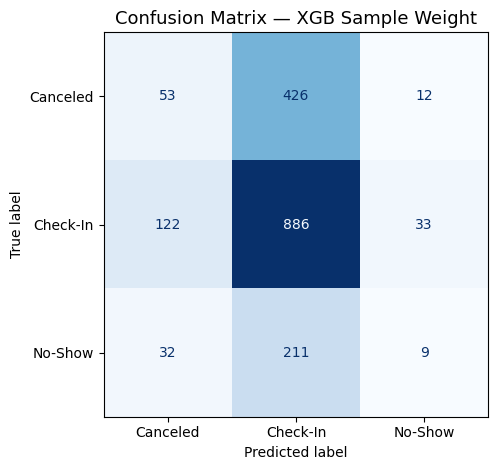

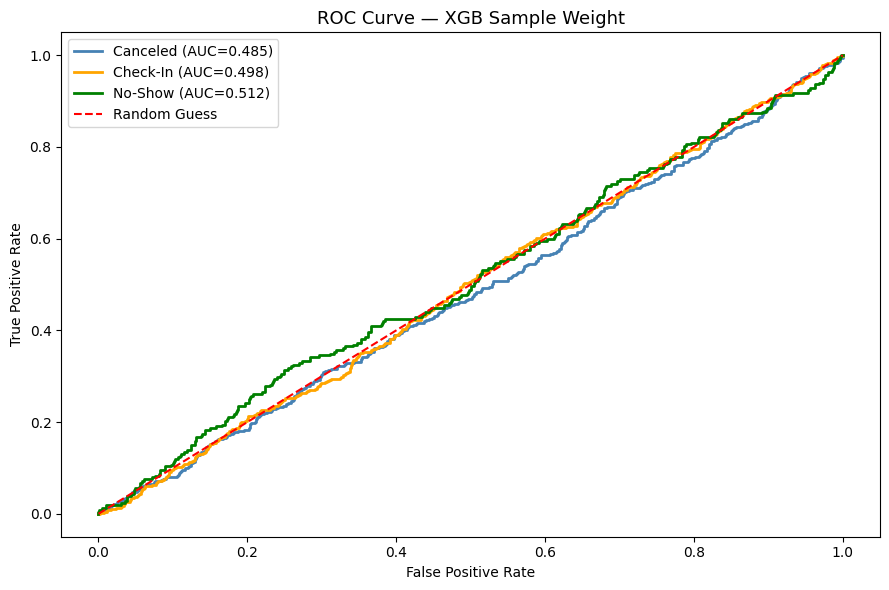

In [13]:
xgb_sw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_sw.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = xgb_sw.predict(X_val)
y_prob = xgb_sw.predict_proba(X_val)

metrics = evaluate_model("XGB Sample Weight", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.3 SMOTE**


  XGB SMOTE
  Accuracy  : 0.5807
  Precision : 0.3499
  Recall    : 0.3342
  F1 Macro  : 0.2537
  ROC-AUC   : 0.5108

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.47      0.01      0.03       491
    Check-In       0.58      0.99      0.73      1041
     No-Show       0.00      0.00      0.00       252

    accuracy                           0.58      1784
   macro avg       0.35      0.33      0.25      1784
weighted avg       0.47      0.58      0.44      1784



<Figure size 800x600 with 0 Axes>

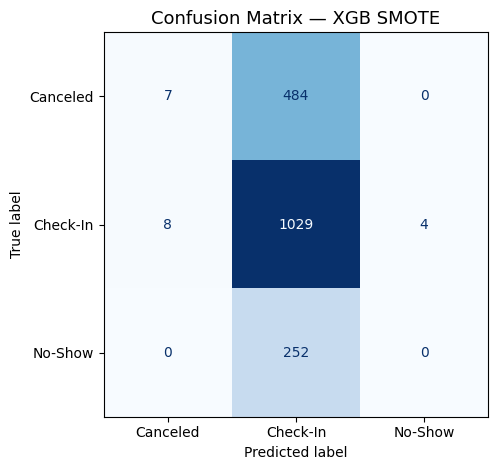

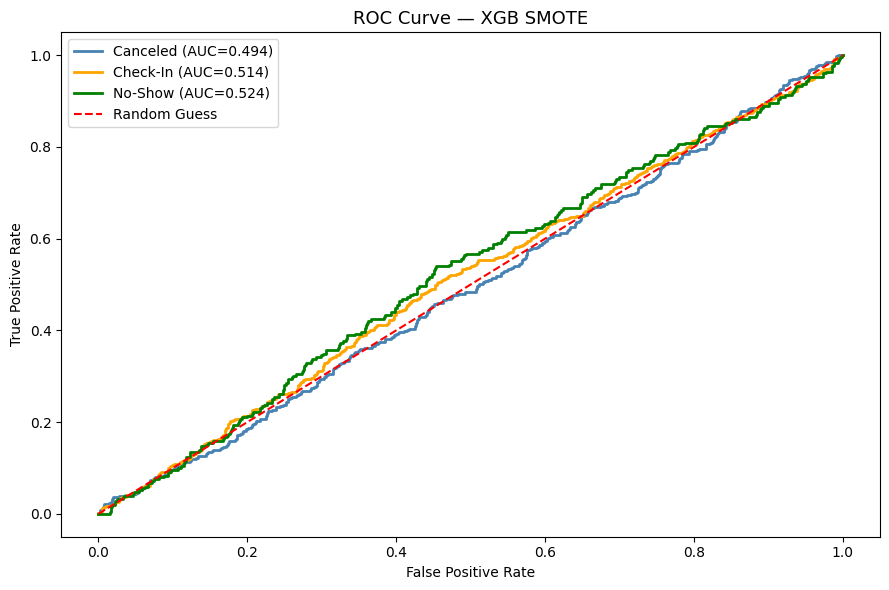

In [14]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_smote.fit(X_train_smote, y_train_smote)
y_pred = xgb_smote.predict(X_val)
y_prob = xgb_smote.predict_proba(X_val)

metrics = evaluate_model("XGB SMOTE", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.4 Random Undersampling**


  XGB Undersampling
  Accuracy  : 0.3161
  Precision : 0.3337
  Recall    : 0.3349
  F1 Macro  : 0.2987
  ROC-AUC   : 0.5069

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.26      0.30      0.28       491
    Check-In       0.59      0.30      0.40      1041
     No-Show       0.15      0.40      0.21       252

    accuracy                           0.32      1784
   macro avg       0.33      0.33      0.30      1784
weighted avg       0.44      0.32      0.34      1784



<Figure size 800x600 with 0 Axes>

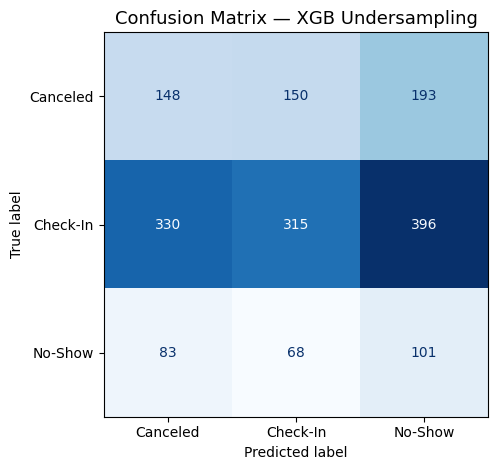

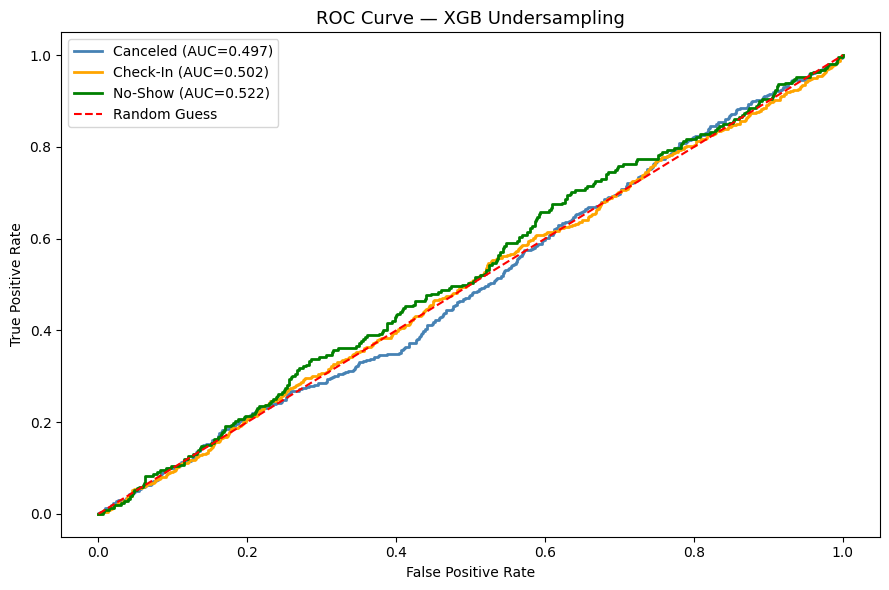

In [15]:
xgb_rus = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_rus.fit(X_train_rus, y_train_rus)
y_pred = xgb_rus.predict(X_val)
y_prob = xgb_rus.predict_proba(X_val)

metrics = evaluate_model("XGB Undersampling", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.5 Exact Validation Distribution Match**


  XGB Exact Val Match
  Accuracy  : 0.5297
  Precision : 0.3356
  Recall    : 0.3359
  F1 Macro  : 0.3087
  ROC-AUC   : 0.5056

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.28      0.16      0.20       491
    Check-In       0.59      0.83      0.69      1041
     No-Show       0.14      0.02      0.03       252

    accuracy                           0.53      1784
   macro avg       0.34      0.34      0.31      1784
weighted avg       0.44      0.53      0.46      1784



<Figure size 800x600 with 0 Axes>

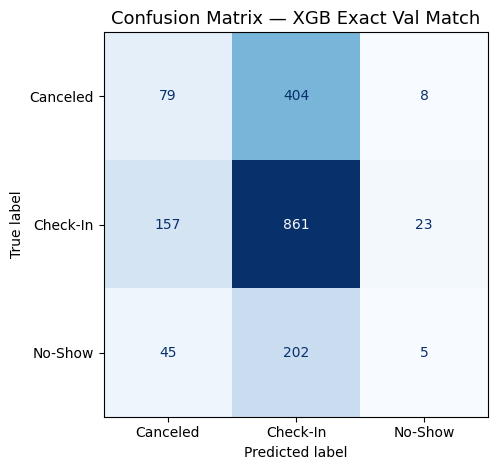

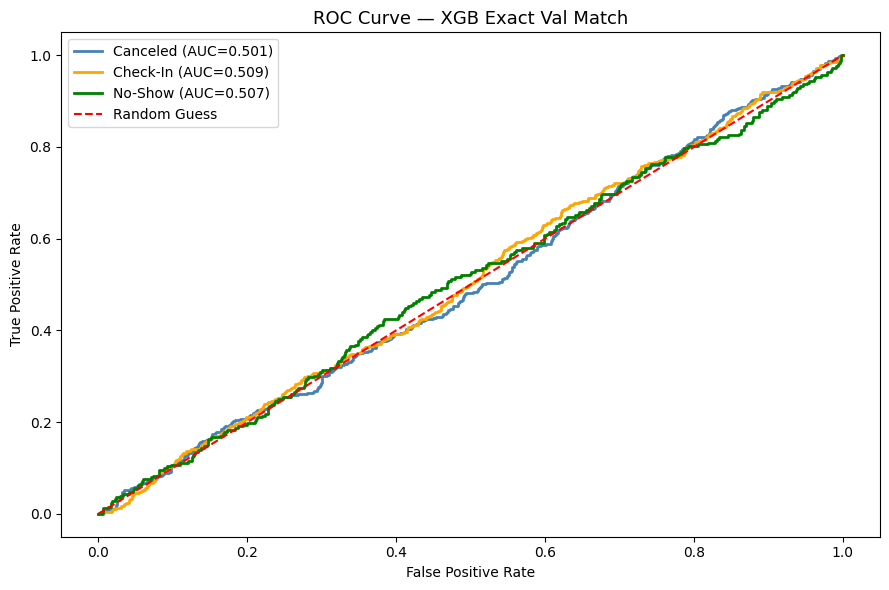

In [16]:
xgb_exact = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_exact.fit(X_train_exact, y_train_exact)
y_pred = xgb_exact.predict(X_val)
y_prob = xgb_exact.predict_proba(X_val)

metrics = evaluate_model("XGB Exact Val Match", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.6 Exact Val Match + Sample Weights**


  XGB Exact Match + SW
  Accuracy  : 0.4215
  Precision : 0.3312
  Recall    : 0.3342
  F1 Macro  : 0.3277
  ROC-AUC   : 0.5094

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.41      0.34       491
    Check-In       0.60      0.51      0.55      1041
     No-Show       0.11      0.09      0.10       252

    accuracy                           0.42      1784
   macro avg       0.33      0.33      0.33      1784
weighted avg       0.44      0.42      0.43      1784



<Figure size 800x600 with 0 Axes>

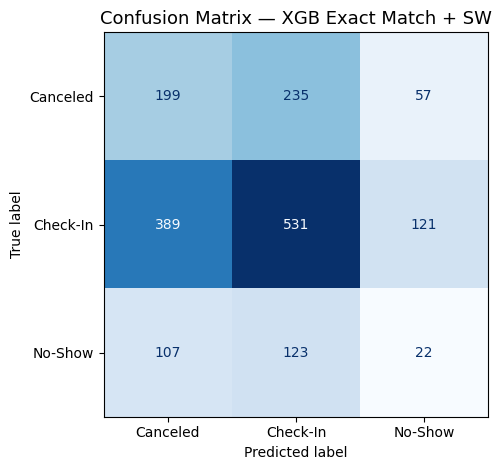

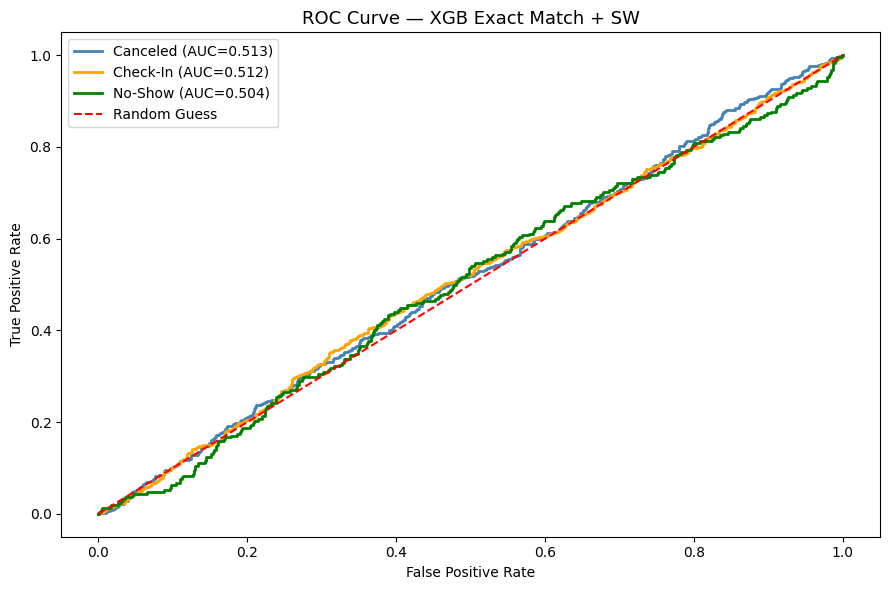

In [17]:
xgb_exact_sw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_exact_sw.fit(X_train_exact, y_train_exact,
                  sample_weight=sample_weights_exact)
y_pred = xgb_exact_sw.predict(X_val)
y_prob = xgb_exact_sw.predict_proba(X_val)

metrics = evaluate_model("XGB Exact Match + SW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.7 Undersampling + Sample Weights**


  XGB Undersample + SW
  Accuracy  : 0.2517
  Precision : 0.3354
  Recall    : 0.3388
  F1 Macro  : 0.2529
  ROC-AUC   : 0.5

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.26      0.32      0.29       491
    Check-In       0.60      0.15      0.24      1041
     No-Show       0.15      0.55      0.24       252

    accuracy                           0.25      1784
   macro avg       0.34      0.34      0.25      1784
weighted avg       0.44      0.25      0.25      1784



<Figure size 800x600 with 0 Axes>

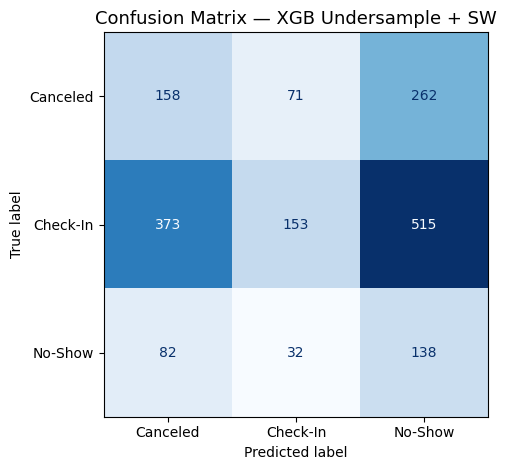

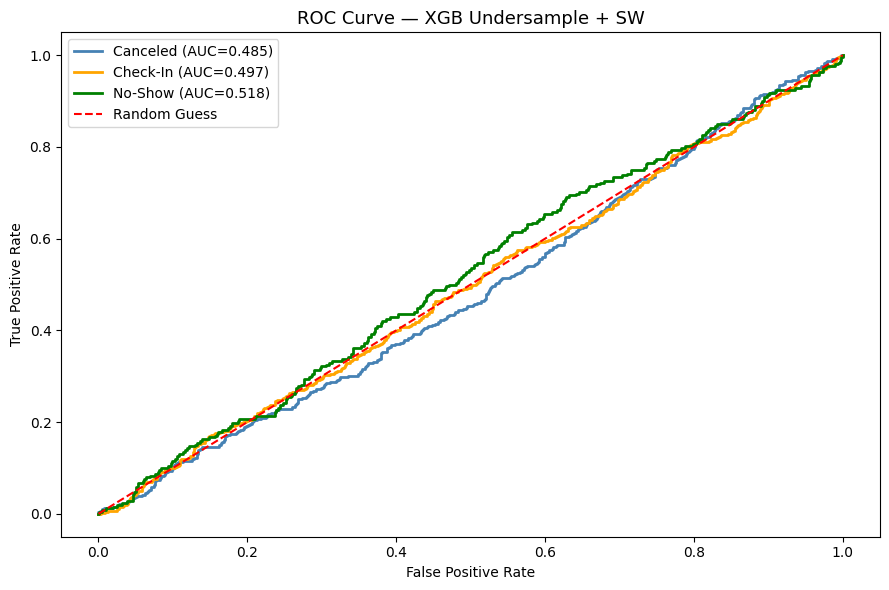

In [18]:
sample_weights_rus = compute_sample_weight(
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    y=y_train_rus
)

xgb_rus_sw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_rus_sw.fit(X_train_rus, y_train_rus,
                sample_weight=sample_weights_rus)
y_pred = xgb_rus_sw.predict(X_val)
y_prob = xgb_rus_sw.predict_proba(X_val)

metrics = evaluate_model("XGB Undersample + SW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

### **6.8 SMOTE + Sample Weights**


  XGB SMOTE + SW
  Accuracy  : 0.523
  Precision : 0.3361
  Recall    : 0.3354
  F1 Macro  : 0.3122
  ROC-AUC   : 0.5028

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.25      0.11      0.15       491
    Check-In       0.59      0.83      0.69      1041
     No-Show       0.17      0.07      0.10       252

    accuracy                           0.52      1784
   macro avg       0.34      0.34      0.31      1784
weighted avg       0.44      0.52      0.46      1784



<Figure size 800x600 with 0 Axes>

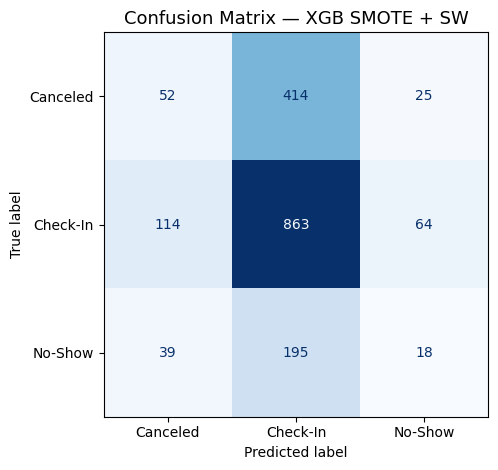

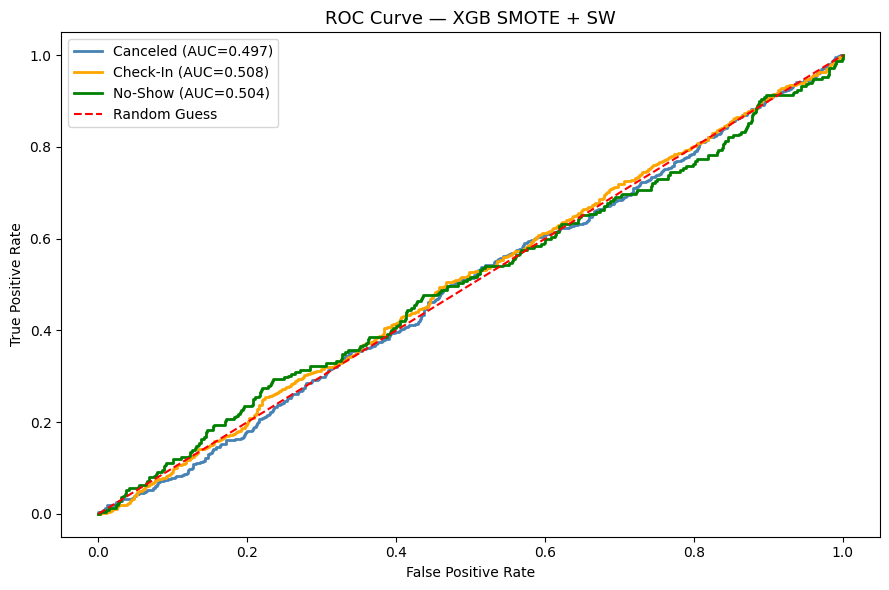

In [19]:
sample_weights_smote = compute_sample_weight(
    class_weight={0: 3.0, 1: 1.0, 2: 4.0},
    y=y_train_smote
)

xgb_smote_sw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_smote_sw.fit(X_train_smote, y_train_smote,
                  sample_weight=sample_weights_smote)
y_pred = xgb_smote_sw.predict(X_val)
y_prob = xgb_smote_sw.predict_proba(X_val)

metrics = evaluate_model("XGB SMOTE + SW", y_val, y_pred,
                          y_prob, y_val_bin, le_target.classes_)
results.append(metrics)

---
## **7. Sampling Comparison Table**

In [20]:
results_df = pd.DataFrame(results)

print("=" * 95)
print("       XGB — FULL SAMPLING METHOD COMPARISON")
print("=" * 95)
print(f"{'Model':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1 Macro':>9} {'ROC-AUC':>9}")
print("-" * 95)
for _, row in results_df.iterrows():
    print(f"{row['name']:<28} {row['accuracy']:>9} {row['precision']:>10} {row['recall']:>8} {row['f1_macro']:>9} {row['roc_auc']:>9}")
print("=" * 95)

print(f"\nBest by F1 Macro:  {results_df.loc[results_df['f1_macro'].idxmax(), 'name']} ({results_df['f1_macro'].max()})")
print(f"Best by Recall:    {results_df.loc[results_df['recall'].idxmax(), 'name']} ({results_df['recall'].max()})")
print(f"Best by ROC-AUC:   {results_df.loc[results_df['roc_auc'].idxmax(), 'name']} ({results_df['roc_auc'].max()})")
print(f"Best by Precision: {results_df.loc[results_df['precision'].idxmax(), 'name']} ({results_df['precision'].max()})")

       XGB — FULL SAMPLING METHOD COMPARISON
Model                         Accuracy  Precision   Recall  F1 Macro   ROC-AUC
-----------------------------------------------------------------------------------------------
XGB Baseline                    0.5807     0.3174   0.3342    0.2538    0.5027
XGB Sample Weight               0.5314     0.3348   0.3316    0.3006    0.4983
XGB SMOTE                       0.5807     0.3499   0.3342    0.2537    0.5108
XGB Undersampling               0.3161     0.3337   0.3349    0.2987    0.5069
XGB Exact Val Match             0.5297     0.3356   0.3359    0.3087    0.5056
XGB Exact Match + SW            0.4215     0.3312   0.3342    0.3277    0.5094
XGB Undersample + SW            0.2517     0.3354   0.3388    0.2529       0.5
XGB SMOTE + SW                   0.523     0.3361   0.3354    0.3122    0.5028

Best by F1 Macro:  XGB Exact Match + SW (0.3277)
Best by Recall:    XGB Undersample + SW (0.3388)
Best by ROC-AUC:   XGB SMOTE (0.5108)
Best by Pre

---
## **8. RandomizedSearchCV — Hyperparameter Tuning**

**Update `X_tune`, `y_tune`, and `fit_params` below based on which method won in the comparison table.**

In [30]:
X_tune = X_train_exact
y_tune = y_train_exact
tune_sample_weight = sample_weights_exact

print(f"Tuning on: {len(X_tune)} samples")
print(f"Sample weight: Yes")

Tuning on: 10000 samples
Sample weight: Yes


In [31]:
param_grid = {
    "n_estimators"     : [200, 300, 400, 500],
    "max_depth"        : [3, 4, 6, 8, 10],
    "learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "subsample"        : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.5, 0.6, 0.7, 0.8, 1.0],
    "reg_alpha"        : [0, 0.01, 0.1, 1.0],
    "reg_lambda"       : [0.5, 1.0, 2.0, 5.0],
    "min_child_weight" : [1, 3, 5, 7]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting RandomizedSearchCV (n_iter=20, cv=3)...")

if tune_sample_weight is not None:
    xgb_search.fit(X_tune, y_tune, sample_weight=tune_sample_weight)
else:
    xgb_search.fit(X_tune, y_tune)

print(f"\nBest Parameters: {xgb_search.best_params_}")
print(f"Best CV F1 Macro: {xgb_search.best_score_:.4f}")

Starting RandomizedSearchCV (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV F1 Macro: 0.3040


---
## **9. Final XGBoost Model — Evaluate on Validation**

Final model params:
  subsample: 1.0
  reg_lambda: 0.5
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 5
  max_depth: 8
  learning_rate: 0.2
  colsample_bytree: 1.0

Trained on: 10000 samples

  XGB Final (Tuned)
  Accuracy  : 0.4765
  Precision : 0.3355
  Recall    : 0.3381
  F1 Macro  : 0.3324
  ROC-AUC   : 0.5099

Classification Report:
              precision    recall  f1-score   support

    Canceled       0.29      0.28      0.28       491
    Check-In       0.59      0.67      0.63      1041
     No-Show       0.13      0.06      0.08       252

    accuracy                           0.48      1784
   macro avg       0.34      0.34      0.33      1784
weighted avg       0.44      0.48      0.46      1784



<Figure size 800x600 with 0 Axes>

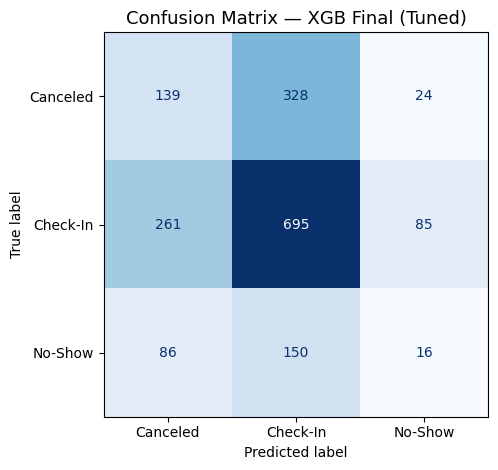

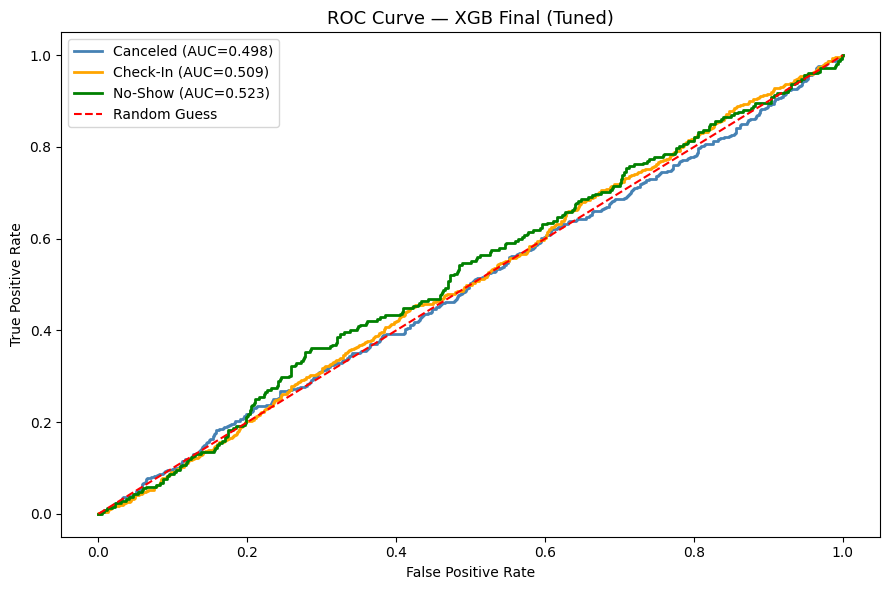


  Pre-tuning best F1 Macro:  0.3277
  Post-tuning F1 Macro:      0.3324
  Change:                    +0.0047


In [32]:
xgb_final = xgb_search.best_estimator_

print("Final model params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nTrained on: {X_tune.shape[0]} samples")

y_pred_final = xgb_final.predict(X_val)
y_prob_final = xgb_final.predict_proba(X_val)

metrics_final = evaluate_model("XGB Final (Tuned)", y_val, y_pred_final,
                                y_prob_final, y_val_bin, le_target.classes_)

# Compare against best pre-tuning result
print(f"\n{'='*55}")
print(f"  Pre-tuning best F1 Macro:  {results_df['f1_macro'].max():.4f}")
print(f"  Post-tuning F1 Macro:      {metrics_final['f1_macro']:.4f}")
improvement = metrics_final['f1_macro'] - results_df['f1_macro'].max()
print(f"  Change:                    {improvement:+.4f}")
print(f"{'='*55}")

---
## **10. Feature Importance — Gini (gain)**

Top 15 Features by Importance:
                    feature  importance
                  Meal_Type    0.052296
     Previous_Cancellations    0.037246
Deposit_type_Non_Refundable    0.036946
        Country_region_West    0.033562
        Ethnicity_caucasian    0.032499
    Deposit_type_Refundable    0.032261
       Country_region_North    0.032237
           Stay_Length_Days    0.030767
   Ethnicity_Asian_American    0.030473
           Ethnicity_Latino    0.030242
             Lead_Time_Days    0.029967
     Booking_channel_Direct    0.029935
              Checkin_month    0.029287
          Checkin_dayofweek    0.029125
       Required_Car_Parking    0.028733


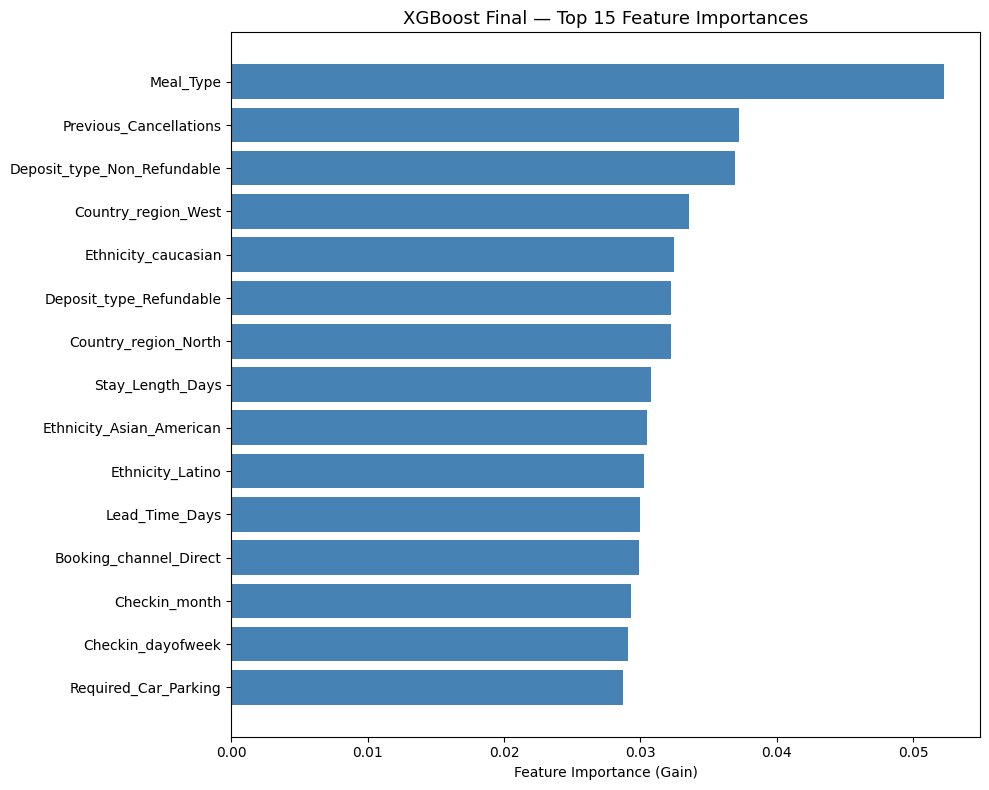


All features:
                    feature  importance
                  Meal_Type    0.052296
     Previous_Cancellations    0.037246
Deposit_type_Non_Refundable    0.036946
        Country_region_West    0.033562
        Ethnicity_caucasian    0.032499
    Deposit_type_Refundable    0.032261
       Country_region_North    0.032237
           Stay_Length_Days    0.030767
   Ethnicity_Asian_American    0.030473
           Ethnicity_Latino    0.030242
             Lead_Time_Days    0.029967
     Booking_channel_Direct    0.029935
              Checkin_month    0.029287
          Checkin_dayofweek    0.029125
       Required_Car_Parking    0.028733
              Use_Promotion    0.028728
          Educational_Level    0.028617
                     Adults    0.028164
              Booking_month    0.028033
                     Babies    0.027479
                  Room_Rate    0.027372
      Hotel_Type_City_Hotel    0.027233
              Discount_Rate    0.027118
               Total_Gues

In [33]:
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Features by Importance:")
print(feat_imp.head(15).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 8))
top15 = feat_imp.head(15)
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost Final — Top 15 Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

# Full table
print("\nAll features:")
print(feat_imp.to_string(index=False))

---
## **11. Permutation Importance**

Computing permutation importance on validation set...

Top 15 Features by Permutation Importance:
                feature  importance_mean  importance_std
          Discount_Rate         0.005549        0.004431
      Hotel_Type_Resort         0.004260        0.002057
  Hotel_Type_City_Hotel         0.003642        0.002224
   Required_Car_Parking         0.002839        0.003964
          Checkin_month         0.002340        0.002376
 Booking_channel_Direct         0.002134        0.002296
               Children         0.002072        0.002480
Deposit_type_Refundable         0.001825        0.003975
              Meal_Type         0.001568        0.006978
       Stay_Length_Days         0.001027        0.001161
       Ethnicity_Latino         0.000461        0.003429
    Country_region_West        -0.000032        0.001304
          Use_Promotion        -0.000088        0.002377
                    Age        -0.000252        0.006406
    Ethnicity_caucasian        -0.000821       

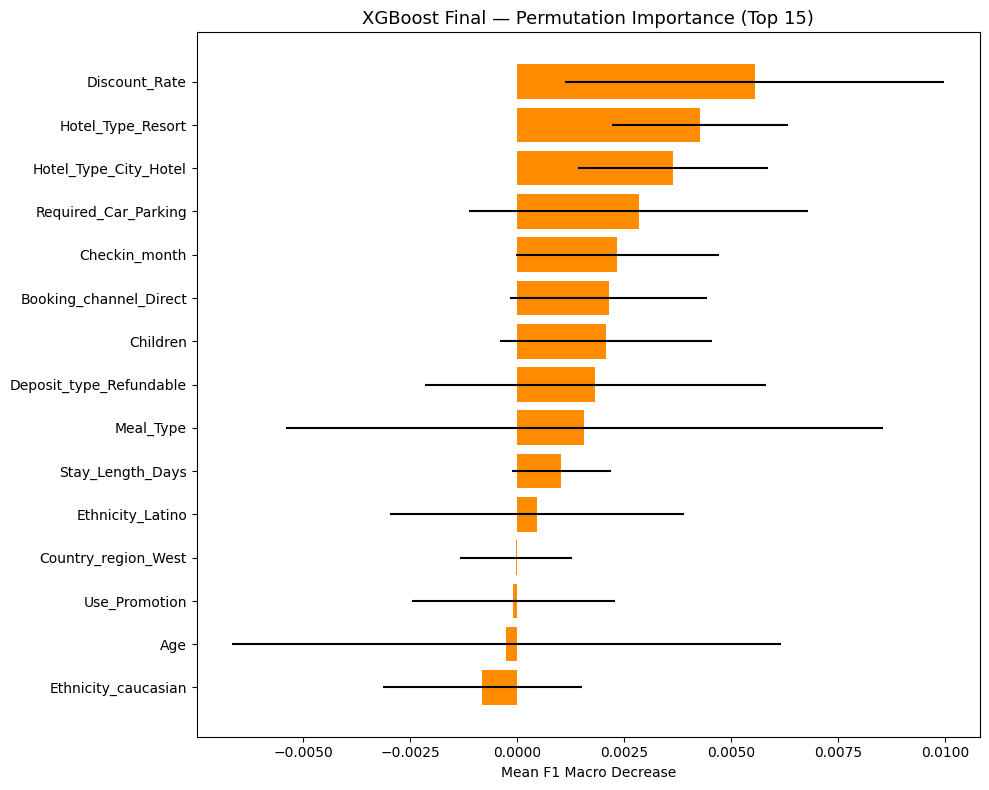

In [25]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance on validation set...")
perm_result = permutation_importance(
    xgb_final, X_val, y_val,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 Features by Permutation Importance:")
print(perm_imp.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top15_perm = perm_imp.head(15)
plt.barh(top15_perm["feature"][::-1], top15_perm["importance_mean"][::-1],
         xerr=top15_perm["importance_std"][::-1], color="darkorange")
plt.xlabel("Mean F1 Macro Decrease")
plt.title("XGBoost Final — Permutation Importance (Top 15)", fontsize=13)
plt.tight_layout()
plt.show()

---
## **12. Save Best Model**

In [26]:
with open("xgb_final_tuned.pkl", "wb") as f:
    pickle.dump(xgb_final, f)

print("Model saved: xgb_final_tuned.pkl")
print(f"\nFinal Metrics:")
for k, v in metrics_final.items():
    print(f"  {k}: {v}")

Model saved: xgb_final_tuned.pkl

Final Metrics:
  name: XGB Final (Tuned)
  accuracy: 0.3133
  precision: 0.3281
  recall: 0.3345
  f1_macro: 0.2961
  roc_auc: 0.4999
